# Evaluate Specific Neurons
The Pena lab have sent the following list of Neurons to investigate.

* GNG.239 / 720575940636165624
* GNG.440 / 720575940635360924
* GNG.PRW.62 / 720575940628743752
* GNG.1255 / 720575940607880578
* GNG.1383 / 720575940620025620
* GNG.1700 / 720575940613935535
* GNG.455 / 720575940633185567
* GNG.375 / 720575940631999080
* GNG.787 / 720575940628997123
* GNG.705 / 720575940630868793

Here's the plan
1. Check to see if the root_ids have already been evaluated
    1. If not run the single neuron evaluation for each
2. Display the figures too
3. Send a summary to Pena lab (csv and .pngs)

## 1. Load in all existing evaluated neurons

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set paths
basepath = "./fauai-13_data/"
classifier_names = ["cell_type", "cell_class", "cell_flow"]

In [2]:
# Now walk through the classifier folders and get a list of all the csv files
csv_files = []
for classifier in classifier_names:
    classifier_path = os.path.join(basepath, classifier)
    for root, dirs, files in os.walk(classifier_path):
        for filename in files:
            if filename.endswith(".csv"):
                csv_files.append(os.path.join(root, filename))
print(f"csv files: {csv_files}")

csv files: ['./fauai-13_data/cell_type/new_nt_results_cell-type_.*VUM.*.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_300_400.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_2600_2700.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_4100_4200.csv', './fauai-13_data/cell_type/new_nt_results_cell-type_DNd.*.csv', './fauai-13_data/cell_type/new_nt_results_cell-type_DNg4.*.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_0_100.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_2800_2900.csv', './fauai-13_data/cell_type/new_nt_results_cell-type_DNg6.*.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_2100_2200.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_4600_4700.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_2700_2800.csv', './fauai-13_data/cell_type/new_nt_results_flow_afferent_range_1000_1100.csv', './fauai-13_data/cell_type/new_n

In [3]:
# Load csvs into single dataframe
nt_results_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
display(nt_results_df.head())
display(nt_results_df.tail())
print(f"Full size: {nt_results_df.shape}")
print("Basic statistics:")
display(nt_results_df.describe())

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,...,Ser_ratio,DA_ratio,Unknown_ratio,GABA_clusters,ACh_clusters,Glut_clusters,Oct_clusters,Ser_clusters,DA_clusters,Unknown_clusters
0,720575940624394790,cell_type,OA-VUMa8,30679,400,0.25,0.142857,0.01,0.014277,0.04772,...,0.070341,0.163239,0.000554,False,True,False,True,True,True,False
1,720575940624394790,cell_type,OA-VUMa8,30679,400,0.25,0.142857,0.05,0.014277,0.04772,...,0.070341,0.163239,0.000554,False,False,False,True,False,True,False
2,720575940624394790,cell_type,OA-VUMa8,30679,400,0.25,0.142857,0.10,0.014277,0.04772,...,0.070341,0.163239,0.000554,False,False,False,True,False,False,False
3,720575940624394790,cell_type,OA-VUMa8,30679,400,0.25,0.040000,0.01,0.014277,0.04772,...,0.070341,0.163239,0.000554,False,True,False,True,True,True,False
4,720575940624394790,cell_type,OA-VUMa8,30679,400,0.25,0.040000,0.05,0.014277,0.04772,...,0.070341,0.163239,0.000554,False,False,False,True,False,False,False


,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,...,Ser_ratio,DA_ratio,Unknown_ratio,GABA_clusters,ACh_clusters,Glut_clusters,Oct_clusters,Ser_clusters,DA_clusters,Unknown_clusters
66413,720575940626993694,flow,efferent,1222,400,0.25,0.02,0.05,0.079378,0.447627,...,0.181669,0.022913,0.003273,False,True,False,False,False,False,False
66414,720575940626993694,flow,efferent,1222,400,0.25,0.02,0.10,0.079378,0.447627,...,0.181669,0.022913,0.003273,False,False,False,False,False,False,False
66415,720575940626993694,flow,efferent,1222,400,0.25,0.01,0.01,0.079378,0.447627,...,0.181669,0.022913,0.003273,True,True,True,True,True,True,False
66416,720575940626993694,flow,efferent,1222,400,0.25,0.01,0.05,0.079378,0.447627,...,0.181669,0.022913,0.003273,False,False,False,False,False,False,False
66417,720575940626993694,flow,efferent,1222,400,0.25,0.01,0.10,0.079378,0.447627,...,0.181669,0.022913,0.003273,False,False,False,False,False,False,False


Full size: (66418, 22)
Basic statistics:


,root_id,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,Glut_ratio,Oct_ratio,Ser_ratio,DA_ratio,Unknown_ratio
count,6.641800e+04,66418.000000,66418.0,66418.00,66418.000000,66418.000000,66418.000000,66418.000000,66418.000000,66418.000000,66418.000000,66418.000000,66418.000000
mean,7.205759e+17,2965.747267,400.0,0.25,0.058571,0.047259,0.115699,0.558404,0.125599,0.023893,0.126203,0.049453,0.000750
std,1.020685e+07,4148.020528,0.0,0.00,0.054316,0.037308,0.178981,0.297214,0.164043,0.074049,0.157098,0.062553,0.001266
min,7.205759e+17,401.000000,400.0,0.25,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000657,0.000000,0.000000
25%,7.205759e+17,796.000000,400.0,0.25,0.020000,0.010000,0.011596,0.284689,0.023457,0.001657,0.028788,0.011648,0.000000
50%,7.205759e+17,1552.000000,400.0,0.25,0.040000,0.050000,0.037542,0.621106,0.061176,0.005009,0.067273,0.028689,0.000242
75%,7.205759e+17,3765.000000,400.0,0.25,0.142857,0.100000,0.120635,0.827229,0.151323,0.014320,0.158940,0.062224,0.001045
max,7.205759e+17,95361.000000,400.0,0.25,0.142857,0.100000,0.914250,0.994932,0.901974,0.840774,0.971936,0.710801,0.021531


In [4]:
# Check for duplicates
duplicates = nt_results_df[nt_results_df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 0


### 1a. Check if the Chosen Neurons are present in the dataframe

In [5]:
chosen_root_ids = [
    720575940636165624,
    720575940635360924,
    720575940628743752,
    720575940607880578,
    720575940620025620,
    720575940613935535,
    720575940633185567,
    720575940631999080,
    720575940628997123,
    720575940630868793
]

chosen_nt_results_df = nt_results_df[nt_results_df['root_id'].isin(chosen_root_ids)]
display(chosen_nt_results_df)
print(f"There are {chosen_nt_results_df['root_id'].nunique()} chosen root IDs.")

missing_roots = []
available_root_ids = chosen_nt_results_df['root_id'].unique()
for root_id in chosen_root_ids:
    if root_id not in available_root_ids:
        missing_roots.append(root_id)
    else:
        print(f"Root ID {root_id} is available.")

print(f"Missing root IDs: {missing_roots}")


,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,...,Ser_ratio,DA_ratio,Unknown_ratio,GABA_clusters,ACh_clusters,Glut_clusters,Oct_clusters,Ser_clusters,DA_clusters,Unknown_clusters
52030,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.01,0.176113,0.311066,...,0.208502,0.044534,0.000000,True,True,True,True,True,True,NaN
52031,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.05,0.176113,0.311066,...,0.208502,0.044534,0.000000,True,True,True,False,True,False,NaN
52032,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.10,0.176113,0.311066,...,0.208502,0.044534,0.000000,True,False,False,False,False,False,NaN
52033,720575940628997123,flow,efferent,1482,400,0.25,0.040000,0.01,0.176113,0.311066,...,0.208502,0.044534,0.000000,True,True,True,True,True,True,NaN
52034,720575940628997123,flow,efferent,1482,400,0.25,0.040000,0.05,0.176113,0.311066,...,0.208502,0.044534,0.000000,True,False,True,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63929,720575940620025620,flow,efferent,925,400,0.25,0.020000,0.05,0.102703,0.432432,...,0.198919,0.044324,0.002162,False,True,False,False,False,False,False
63930,720575940620025620,flow,efferent,925,400,0.25,0.020000,0.10,0.102703,0.432432,...,0.198919,0.044324,0.002162,False,True,False,False,False,False,False
63931,720575940620025620,flow,efferent,925,400,0.25,0.010000,0.01,0.102703,0.432432,...,0.198919,0.044324,0.002162,True,True,True,False,True,True,False
63932,720575940620025620,flow,efferent,925,400,0.25,0.010000,0.05,0.102703,0.432432,...,0.198919,0.044324,0.002162,False,True,False,False,False,False,False


There are 10 chosen root IDs.
Root ID 720575940636165624 is available.
Root ID 720575940635360924 is available.
Root ID 720575940628743752 is available.
Root ID 720575940607880578 is available.
Root ID 720575940620025620 is available.
Root ID 720575940613935535 is available.
Root ID 720575940633185567 is available.
Root ID 720575940631999080 is available.
Root ID 720575940628997123 is available.
Root ID 720575940630868793 is available.
Missing root IDs: []


Ok great all 10 are included. Let's check the classification_systems and cell_types

In [6]:
print(f"Classification Systems: {chosen_nt_results_df['classification_system'].unique()}")
print(f"Cell Types: {chosen_nt_results_df['cell_type'].unique()}")

Classification Systems: ['flow']
Cell Types: ['efferent']


They are all `efferent` neurons from `flow`

### 1b. Now calculate whether the neurons are co-transmitting or not

In [7]:
## Get list of thresholds
ratio_thresholds = [1/6, 1/5, 1/4, 1/3, 1/2] #NB These are added as a customiseable feature here
softmax_thresholds = chosen_nt_results_df["softmax_threshold"].unique().tolist()
bandwidth_quantile_values = chosen_nt_results_df["bandwidth_quantile_value"].unique().tolist()
min_synapses_ratio_values = chosen_nt_results_df["min_synapses_ratio_value"].unique().tolist()

#### 1bi. Add the ratio threshold predictions

In [8]:
original_nt_results_df = chosen_nt_results_df.copy()
NT_ratio_columns = ["GABA_ratio", "ACh_ratio", "Glut_ratio", "Oct_ratio", "Ser_ratio", "DA_ratio", "Unknown_ratio"]

for i, ratio in enumerate(ratio_thresholds):
    print(f"Ratio threshold {i}: {ratio}")
    if i == 0:
        # Add ratio threshold column to DataFrame
        chosen_nt_results_df["ratio_threshold"] = ratio
        # Now add boolean columns for each NT if the NT_ratio >= ratio
        for col in NT_ratio_columns:
            chosen_nt_results_df[f"{col}_above"] = chosen_nt_results_df[col] >= ratio
    else:
        _df = original_nt_results_df.copy()
        _df["ratio_threshold"] = ratio
        for col in NT_ratio_columns:
            _df[f"{col}_above"] = _df[col] >= ratio
        chosen_nt_results_df = pd.concat([chosen_nt_results_df, _df], ignore_index=True)
        print(f"adding {_df.shape[0]} rows, length is now {chosen_nt_results_df.shape[0]}")

display(chosen_nt_results_df)

Ratio threshold 0: 0.16666666666666666
Ratio threshold 1: 0.2
adding 120 rows, length is now 240
Ratio threshold 2: 0.25
adding 120 rows, length is now 360
Ratio threshold 3: 0.3333333333333333
adding 120 rows, length is now 480
Ratio threshold 4: 0.5
adding 120 rows, length is now 600


/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_51761/118620797.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_nt_results_df["ratio_threshold"] = ratio
/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_51761/118620797.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_nt_results_df[f"{col}_above"] = chosen_nt_results_df[col] >= ratio
/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_51761/118620797.py:11: SettingWithCopyWarning: 
A value is trying to be set 

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,...,DA_clusters,Unknown_clusters,ratio_threshold,GABA_ratio_above,ACh_ratio_above,Glut_ratio_above,Oct_ratio_above,Ser_ratio_above,DA_ratio_above,Unknown_ratio_above
0,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.01,0.176113,0.311066,...,True,NaN,0.166667,True,True,True,False,True,False,False
1,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.05,0.176113,0.311066,...,False,NaN,0.166667,True,True,True,False,True,False,False
2,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.10,0.176113,0.311066,...,False,NaN,0.166667,True,True,True,False,True,False,False
3,720575940628997123,flow,efferent,1482,400,0.25,0.040000,0.01,0.176113,0.311066,...,True,NaN,0.166667,True,True,True,False,True,False,False
4,720575940628997123,flow,efferent,1482,400,0.25,0.040000,0.05,0.176113,0.311066,...,False,NaN,0.166667,True,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,720575940620025620,flow,efferent,925,400,0.25,0.020000,0.05,0.102703,0.432432,...,False,False,0.500000,False,False,False,False,False,False,False
596,720575940620025620,flow,efferent,925,400,0.25,0.020000,0.10,0.102703,0.432432,...,False,False,0.500000,False,False,False,False,False,False,False
597,720575940620025620,flow,efferent,925,400,0.25,0.010000,0.01,0.102703,0.432432,...,True,False,0.500000,False,False,False,False,False,False,False
598,720575940620025620,flow,efferent,925,400,0.25,0.010000,0.05,0.102703,0.432432,...,False,False,0.500000,False,False,False,False,False,False,False


#### 1bii. Create a joint prediction between the cluster and ratio predictions

In [9]:
nts = ["GABA", "ACh", "Glut", "Oct", "Ser", "DA", "Unknown"]
# Now create a joint prediction between the cluster and ratio predictions
new_cols = []
for nt in nts:
    col_name = f"{nt}_joint_prediction"
    chosen_nt_results_df[col_name] = chosen_nt_results_df[f"{nt}_ratio_above"] | chosen_nt_results_df[f"{nt}_clusters"]
    new_cols.append(col_name)

chosen_nt_results_df["num_nts"] = chosen_nt_results_df[new_cols].sum(axis=1)
chosen_nt_results_df["is_cotransmitting"] = chosen_nt_results_df["num_nts"] > 1
chosen_nt_results_df.head()

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,...,Unknown_ratio_above,GABA_joint_prediction,ACh_joint_prediction,Glut_joint_prediction,Oct_joint_prediction,Ser_joint_prediction,DA_joint_prediction,Unknown_joint_prediction,num_nts,is_cotransmitting
0,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.01,0.176113,0.311066,...,False,True,True,True,True,True,True,False,6,True
1,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.05,0.176113,0.311066,...,False,True,True,True,False,True,False,False,4,True
2,720575940628997123,flow,efferent,1482,400,0.25,0.142857,0.10,0.176113,0.311066,...,False,True,True,True,False,True,False,False,4,True
3,720575940628997123,flow,efferent,1482,400,0.25,0.040000,0.01,0.176113,0.311066,...,False,True,True,True,True,True,True,False,6,True
4,720575940628997123,flow,efferent,1482,400,0.25,0.040000,0.05,0.176113,0.311066,...,False,True,True,True,False,True,False,False,4,True


In [11]:
# Save chosen_nt_results_df to a CSV file
chosen_nt_results_df.to_csv("./fauai-15_data/chosen_nt_results_all-thresholds.csv", index=False)

#### 1biii. Trim down to the "best" threshold settings

In [12]:
# Chosen thresholds from fauai-14
chosen_ratio = 0.2
bandwidth = 0.01
min_synapses = 0.05

In [14]:
final_nt_results_df = chosen_nt_results_df[
                (chosen_nt_results_df["ratio_threshold"] == chosen_ratio) &
                (chosen_nt_results_df["bandwidth_quantile_value"] == bandwidth) &
                (chosen_nt_results_df["min_synapses_ratio_value"] == min_synapses)
            ]
final_nt_results_df.to_csv("./fauai-15_data/final_nt_results.csv", index=False)
display(final_nt_results_df)

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA_ratio,ACh_ratio,...,Unknown_ratio_above,GABA_joint_prediction,ACh_joint_prediction,Glut_joint_prediction,Oct_joint_prediction,Ser_joint_prediction,DA_joint_prediction,Unknown_joint_prediction,num_nts,is_cotransmitting
130,720575940628997123,flow,efferent,1482,400,0.25,0.01,0.05,0.176113,0.311066,...,False,True,True,True,False,True,False,False,4,True
142,720575940628743752,flow,efferent,1012,400,0.25,0.01,0.05,0.066206,0.493083,...,False,False,True,False,False,True,False,False,2,True
154,720575940631999080,flow,efferent,6040,400,0.25,0.01,0.05,0.153642,0.153642,...,False,False,False,True,False,False,False,False,1,False
166,720575940613935535,flow,efferent,1243,400,0.25,0.01,0.05,0.288013,0.261464,...,False,True,True,False,False,True,False,False,3,True
178,720575940630868793,flow,efferent,1999,400,0.25,0.01,0.05,0.137069,0.281141,...,False,False,True,True,False,True,False,False,3,True
190,720575940607880578,flow,efferent,984,400,0.25,0.01,0.05,0.087398,0.480691,...,False,False,True,False,False,False,False,False,1,False
202,720575940636165624,flow,efferent,4446,400,0.25,0.01,0.05,0.045884,0.849528,...,False,False,True,False,False,False,False,False,1,False
214,720575940633185567,flow,efferent,1140,400,0.25,0.01,0.05,0.194737,0.329825,...,False,True,True,False,False,True,False,False,3,True
226,720575940635360924,flow,efferent,4274,400,0.25,0.01,0.05,0.018484,0.923959,...,False,False,True,False,False,False,False,False,1,False
238,720575940620025620,flow,efferent,925,400,0.25,0.01,0.05,0.102703,0.432432,...,False,False,True,False,False,False,False,False,1,False


## 2. Plot figures

### 2a. Functions

In [15]:
from decouple import config, Config, RepositoryEnv
from caveclient import CAVEclient
from fafbseg import flywire
from getpass import getpass
from sklearn.cluster import estimate_bandwidth, mean_shift
import navis
import datetime
import signal
import time

/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Checking Client Connections

In [16]:
# Get variables from the .env file
ENV_PATH = "../.env"
config = Config(RepositoryEnv(ENV_PATH))

### CAV Client ###
# Get the CAVE_AUTH_TOKEN
cave_token = config("CAVE_AUTH_TOKEN", default=None)
if not cave_token:
    print("No CAVE token found in the .env file.")
    temp_token = getpass("Token not found in the .env file. Please enter your CAVE token (if you don't have one leave if blank and instructions will appear): ")
    if temp_token:
        cave_token = temp_token
    else:
        print("No CAVE token entered. Follow the information below to get a token.")
        CAVEclient.auth.get_new_token()
if cave_token:
    # Initialize the CAVE client
    client = CAVEclient('flywire_fafb_public')
    auth = client.auth
    tk = auth.token
    if not tk:
        print("Adding the token to your account. You only need to do this once.")
        auth.save_token(cave_token)
    else:
        print("CAVE token already exists in your account. No need to add it again.")

### Get the FLYWIRE_AUTH_TOKEN ###
flywire_token = config("FLYWIRE_AUTH_TOKEN", default=None)
tk = flywire.get_chunkedgraph_secret()
if not tk:
    print("No FLYWIRE token saved. Setting it with the value from the .env file.")
    if not flywire_token:
        flywire_token = getpass("Token not found in the .env file. Please enter your FLYWIRE token (if you don't have one leave if blank and instructions will appear): ")
        if not flywire_token:
            print("No FLYWIRE token entered. Follow the information below to get a token.")
            flywire.get_new_token()
        else:
            print("Setting the FLYWIRE token with the value from the .env file.")
            #Save the secret
            flywire.set_chunkedgraph_secret(flywire_token)
else:
    print("FLYWIRE token already exists in your account. No need to add it again.")

CAVE token already exists in your account. No need to add it again.
FLYWIRE token already exists in your account. No need to add it again.


#### Load Codex information

In [61]:
# Function 1: Get the dataframes
def get_codex_synapse_predictions(root_id, client):
    """
    Function to gather synapse predictions for a given root ID.
    """

    # Pull initial data from the CAVE client
    pre_df = client.materialize.query_table(
        table='synapses_nt_v1',
        filter_in_dict={'pre_pt_root_id': [root_id]},
    )

    return pre_df

# Function 2: Get the neuron skeleton
def get_neuron_skeleton(root_id):
    """
    Function to gather the neuron skeleton for a given root ID.
    """
    neuron_skeleton = flywire.get_skeletons(root_id)

    return neuron_skeleton

# Function 3: Identify NT contributions per neuron
def identify_nt_contributions(pre_df, softmax_threshold=0.25):
    """
    Function to identify neurotransmitter contributions per neuron.
    Inputs:
    pre_df: DataFrame containing synapse predictions with columns for each neurotransmitter type.
    softmax_threshold: Float, the threshold below which a neurotransmitter is considered 'Unknown'.

    Returns:
    nt_counts: a dictionary with counts of each neurotransmitter type.
    synapse_predictions: a numpy array with synapse predictions for each neurotransmitter type. (NB excludes 'Unknown' type)
    """

    #Synapse predictions
    synapse_predictions = np.zeros((len(pre_df), 6), dtype=np.float32)
    for i in range(pre_df.shape[0]):
        row = [pre_df.iloc[i]['gaba'], pre_df.iloc[i]['ach'], pre_df.iloc[i]['glut'], pre_df.iloc[i]['oct'], pre_df.iloc[i]['ser'], pre_df.iloc[i]['da']]
        synapse_predictions[i] = row
        
    # Define neurotransmitter types
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    
    # Initialize counts and filter along softmax values
    nt_counts = {nt: 0 for nt in nt_types}
    softmax_prediction_vals = {nt: [] for nt in nt_types}

    for i in range(pre_df.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        softmax_val = np.max(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        
        # Add the softmax value to the corresponding neurotransmitter type
        softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
        # Increment the count for the neurotransmitter type
        nt_counts[nt_types[synapse_type]] += 1
    nt_ratios = nt_counts.copy()

    # Convert to ratios
    total_synapses = pre_df.shape[0]
    for nt in nt_counts.keys():
        if total_synapses > 0:
            nt_ratios[nt] = nt_counts[nt] / total_synapses
        else:
            nt_ratios[nt] = 0
    
    return nt_counts, nt_ratios, synapse_predictions

In [62]:
def plot_nt_contributions_for_neuron(root_id, ratio_thresh, softmax_threshold, client, suptitle_str, fig_path):
    """
    Function to identify neurotransmitter contributions per neuron.
    Inputs:
    root_id: The root ID of the neuron to analyze.
    client: The CAVE client to use for querying data.
    softmax_thresholds: List, the thresholds below which a neurotransmitter is considered 'Unknown'.
    ratio_thresholds: List, the thresholds above which a neurotransmitter is considered used.
    bandwidth_quantile_values: List, the quantiles to use for bandwidth estimation in clustering.
    min_synapses_ratio_values: List, the ratios of minimum synapses required for a cluster to be considered valid.
    display_fig: Boolean, whether to display the figures or not.
    
    Returns a list of dictionaries with parameter settings.
    """
    # Get the synapse predictions
    pre_df = get_codex_synapse_predictions(root_id, client)
    neuron_results = []
    
    # Identify neurotransmitter contributions
    nt_counts, nt_ratios, synapse_predictions = identify_nt_contributions(pre_df, 0.25)
    print(f"nt_counts: {nt_counts}")
    print(f"nt_ratios: {nt_ratios}")
    neuron_skeleton = get_neuron_skeleton(root_id)
    # Plot the neuron skeleton with neurotransmitter contributions
    fig, ax = plt.subplots(2,4, figsize=(20, 10))

    # Plot the synapse predictions as a heatmap
    sns.heatmap(synapse_predictions, ax=ax[0,0])
    ax[0,0].set_title('Synapse Predictions Heatmap')
    ax[0,0].set_xlabel('Neurotransmitter Type')
    ax[0,0].set_xticks(np.arange(6) + 0.5)
    ax[0,0].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

    # Plot each row of the synapse predictions as a line plot
    for i in range(synapse_predictions.shape[0]):
        ax[0,1].plot(synapse_predictions[i], color='k', label=f'Synapse {i+1}', alpha=0.1)
    mean_predictions = np.mean(synapse_predictions, axis=0)
    median_predictions = np.median(synapse_predictions, axis=0)
    ax[0,1].plot(mean_predictions, label='Mean', color='r')
    ax[0,1].plot(median_predictions, label='Median', color='blue')
    ax[0,1].set_xlabel('Neurotransmitter Type')
    ax[0,1].set_xticks([0, 1, 2, 3, 4, 5])
    ax[0,1].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

    # Plot the neuron skeleton with the synapse predictions - all 3 combinations
    navis.plot2d(neuron_skeleton, ax=ax[1,0], color='k', view='xy')
    navis.plot2d(neuron_skeleton, ax=ax[1,1], color='k', view='yz')
    navis.plot2d(neuron_skeleton, ax=ax[1,2], color='k', view='xz')

    # Define neurotransmitter types and colors
    present_types = set()
    softmax_prediction_vals = {
        'GABA': [],
        'ACh': [],
        'Glut': [],
        'Oct': [],
        'Ser': [],
        'DA': [],
        'Unknown': []
    }
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    colours = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'gray']

    for i in range(synapse_predictions.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(synapse_predictions[i])
        softmax_val = np.max(synapse_predictions[i])
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        colour = colours[synapse_type]
        present_types.add(synapse_type)

        # Add the softmax value to the corresponding neurotransmitter type
        softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
    
        # Find the position of the pre-synapse
        pos = pre_df.iloc[i]['pre_pt_position']
        pos_xy = (pos[0], pos[1])
        pos_yz = (pos[1], pos[2])
        pos_xz = (pos[0], pos[2])
    
        # Plot the synapse prediction on the neuron skeleton
        ax[1,0].plot(pos_xy[0], pos_xy[1], 'o', color=colour, markersize=2, alpha=0.75)
        ax[1,1].plot(pos_yz[0], pos_yz[1], 'o', color=colour, markersize=2, alpha=0.75)
        ax[1,2].plot(pos_xz[0], pos_xz[1], 'o', color=colour, markersize=2, alpha=0.75)

    # Create legend entries only for neurotransmitter types that are present
    legend_elements = []
    for nt_idx in sorted(present_types):
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=colours[nt_idx], markersize=8,
                                        label=nt_types[nt_idx]))

    # Place the legend horizontally below the x-axis
    ax[1,0].legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        borderaxespad=0.,
        ncol=round(len(legend_elements)/2),
        frameon=False
    )
    ax[1,0].set_title('Neuron Skeleton with Synapse Predictions - Coronal')
    ax[1,1].set_title('Neuron Skeleton with Synapse Predictions - Sagittal')
    ax[1,2].set_title('Neuron Skeleton with Synapse Predictions - Axial')
    print(f"nt_counts: {nt_counts}")
    # Plot the counts of each neurotransmitter type
    ax[0,3].bar(nt_counts.keys(), nt_counts.values(), color=colours)
    # ax[0,3].axhline(y=ratio_thresh, color='red', linestyle='--') # add a horizontal bar at the ratio_threshold
    ax[0,3].set_xlabel('Neurotransmitter Type')
    ax[0,3].set_ylabel('Count')
    ax[0,3].set_title('Counts of Neurotransmitter Types')

    # Plot the ratios of each neurotransmitter type
    ax[1,3].bar(nt_ratios.keys(), nt_ratios.values(), color=colours)
    ax[1,3].axhline(y=ratio_thresh, color='red', linestyle='--') # add a horizontal bar at the ratio_threshold
    ax[1,3].set_xlabel('Neurotransmitter Type')
    ax[1,3].set_ylabel('Ratios')
    ax[1,3].set_title('Ratios of Neurotransmitter Types')
    
    # Softmax confidence of the predictions
    sns.stripplot(data=softmax_prediction_vals, ax=ax[0,2])
    ax[0,2].set_title('Softmax Confidence of Predictions')
    ax[0,2].set_xlabel('Neurotransmitter Type')
    ax[0,2].set_ylabel('Softmax Confidence of chosen neurotransmitter')

    plt.suptitle(suptitle_str, fontsize=16)
    plt.tight_layout()
    plt.savefig(fig_path)
    plt.show()


720575940628997123
nt_counts: {'GABA': 261, 'ACh': 461, 'Glut': 301, 'Oct': 84, 'Ser': 309, 'DA': 66, 'Unknown': 0}
nt_ratios: {'GABA': 0.17611336032388664, 'ACh': 0.31106612685560053, 'Glut': 0.20310391363022942, 'Oct': 0.05668016194331984, 'Ser': 0.20850202429149797, 'DA': 0.044534412955465584, 'Unknown': 0.0}


nt_counts: {'GABA': 261, 'ACh': 461, 'Glut': 301, 'Oct': 84, 'Ser': 309, 'DA': 66, 'Unknown': 0}


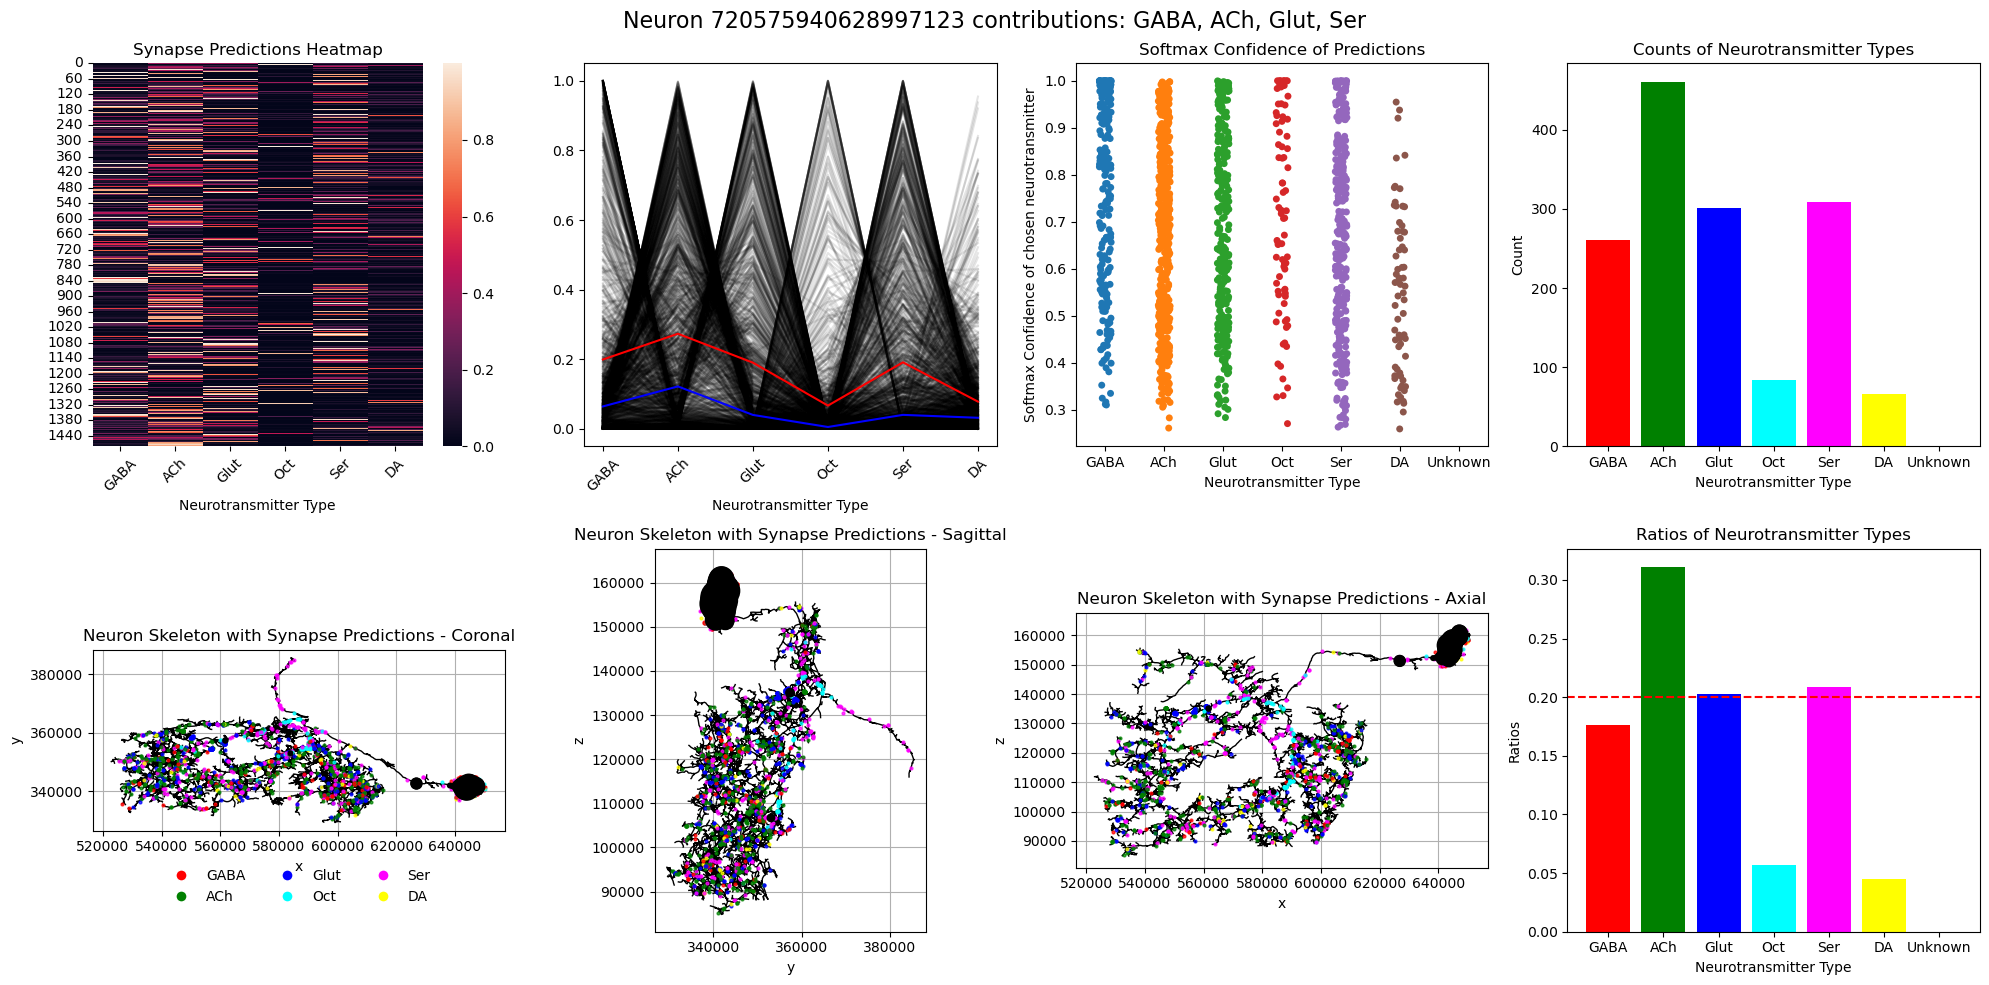

720575940628743752
nt_counts: {'GABA': 67, 'ACh': 499, 'Glut': 118, 'Oct': 46, 'Ser': 246, 'DA': 34, 'Unknown': 2}
nt_ratios: {'GABA': 0.06620553359683795, 'ACh': 0.49308300395256915, 'Glut': 0.116600790513834, 'Oct': 0.045454545454545456, 'Ser': 0.24308300395256918, 'DA': 0.03359683794466403, 'Unknown': 0.001976284584980237}


nt_counts: {'GABA': 67, 'ACh': 499, 'Glut': 118, 'Oct': 46, 'Ser': 246, 'DA': 34, 'Unknown': 2}


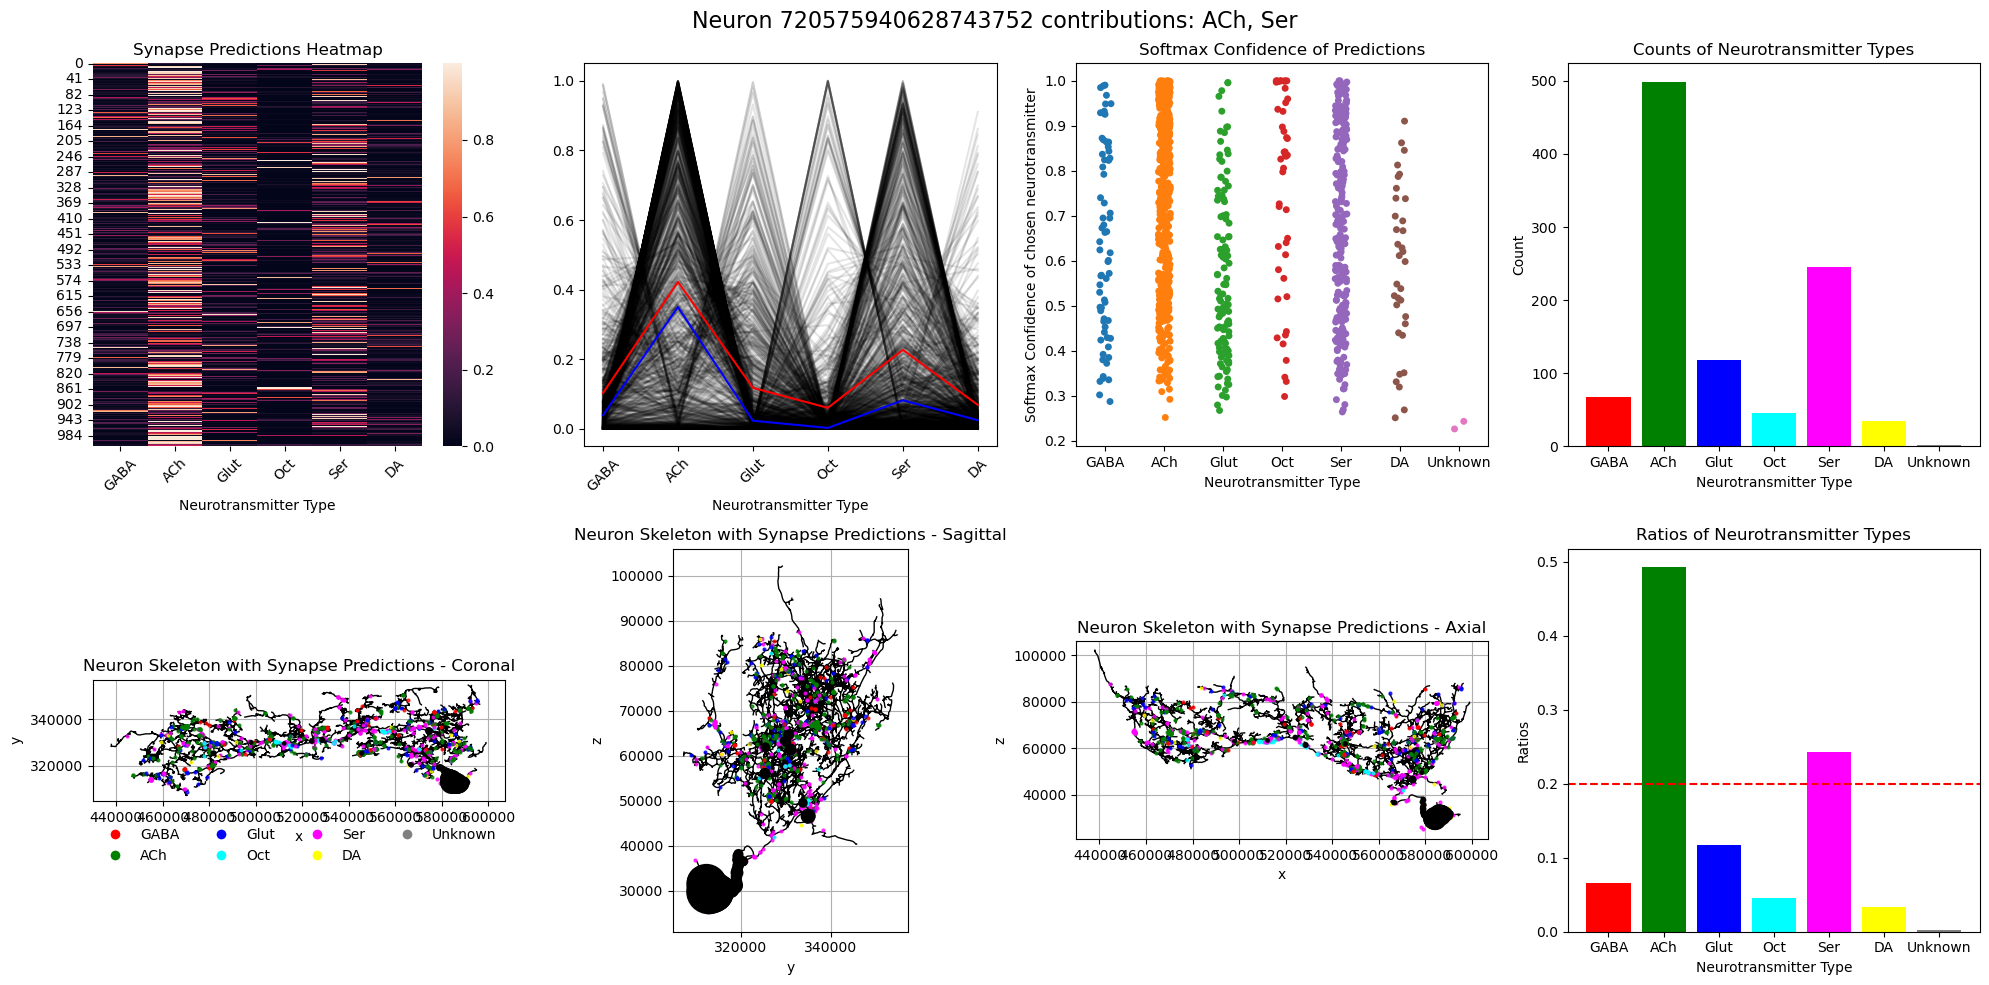

720575940631999080
nt_counts: {'GABA': 928, 'ACh': 928, 'Glut': 4021, 'Oct': 8, 'Ser': 111, 'DA': 41, 'Unknown': 3}
nt_ratios: {'GABA': 0.15364238410596026, 'ACh': 0.15364238410596026, 'Glut': 0.6657284768211921, 'Oct': 0.0013245033112582781, 'Ser': 0.018377483443708608, 'DA': 0.006788079470198676, 'Unknown': 0.0004966887417218543}


nt_counts: {'GABA': 928, 'ACh': 928, 'Glut': 4021, 'Oct': 8, 'Ser': 111, 'DA': 41, 'Unknown': 3}


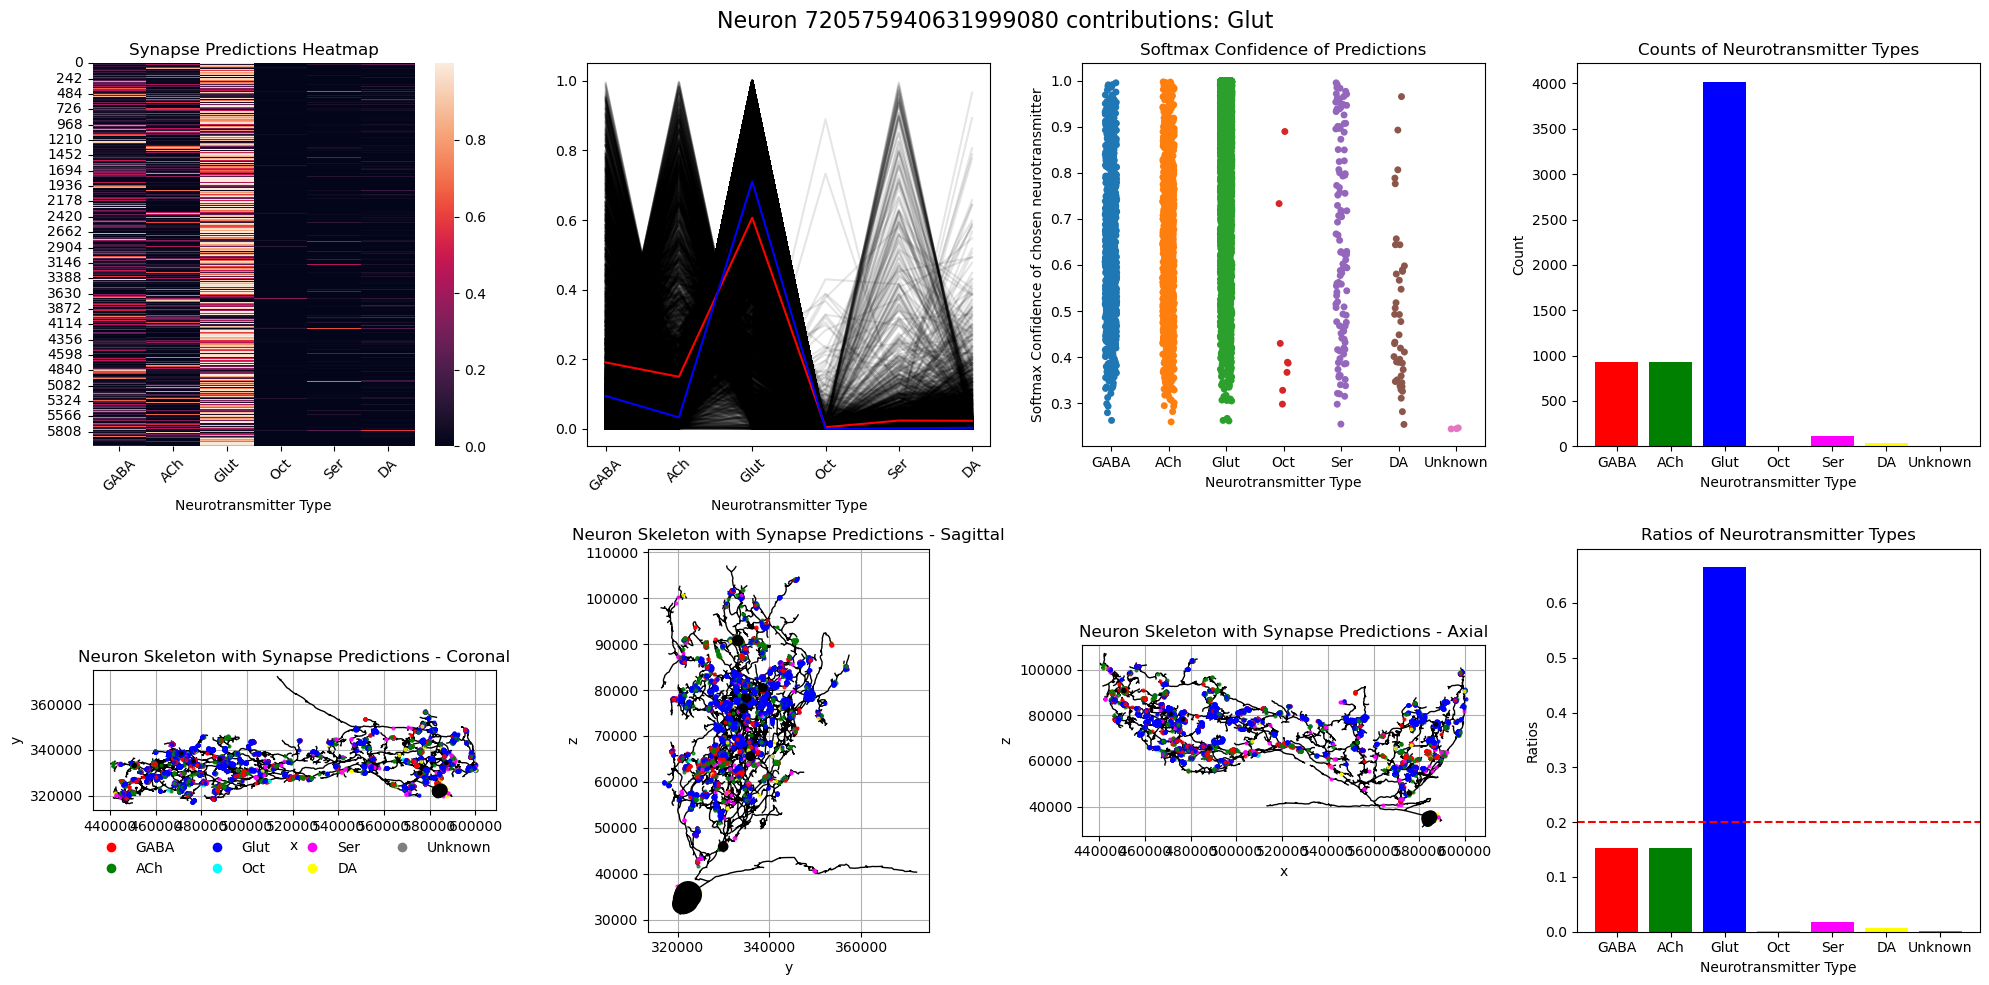

720575940613935535
nt_counts: {'GABA': 358, 'ACh': 325, 'Glut': 77, 'Oct': 171, 'Ser': 299, 'DA': 13, 'Unknown': 0}
nt_ratios: {'GABA': 0.28801287208366855, 'ACh': 0.2614641995172969, 'Glut': 0.061946902654867256, 'Oct': 0.13757039420756234, 'Ser': 0.24054706355591313, 'DA': 0.010458567980691875, 'Unknown': 0.0}


nt_counts: {'GABA': 358, 'ACh': 325, 'Glut': 77, 'Oct': 171, 'Ser': 299, 'DA': 13, 'Unknown': 0}


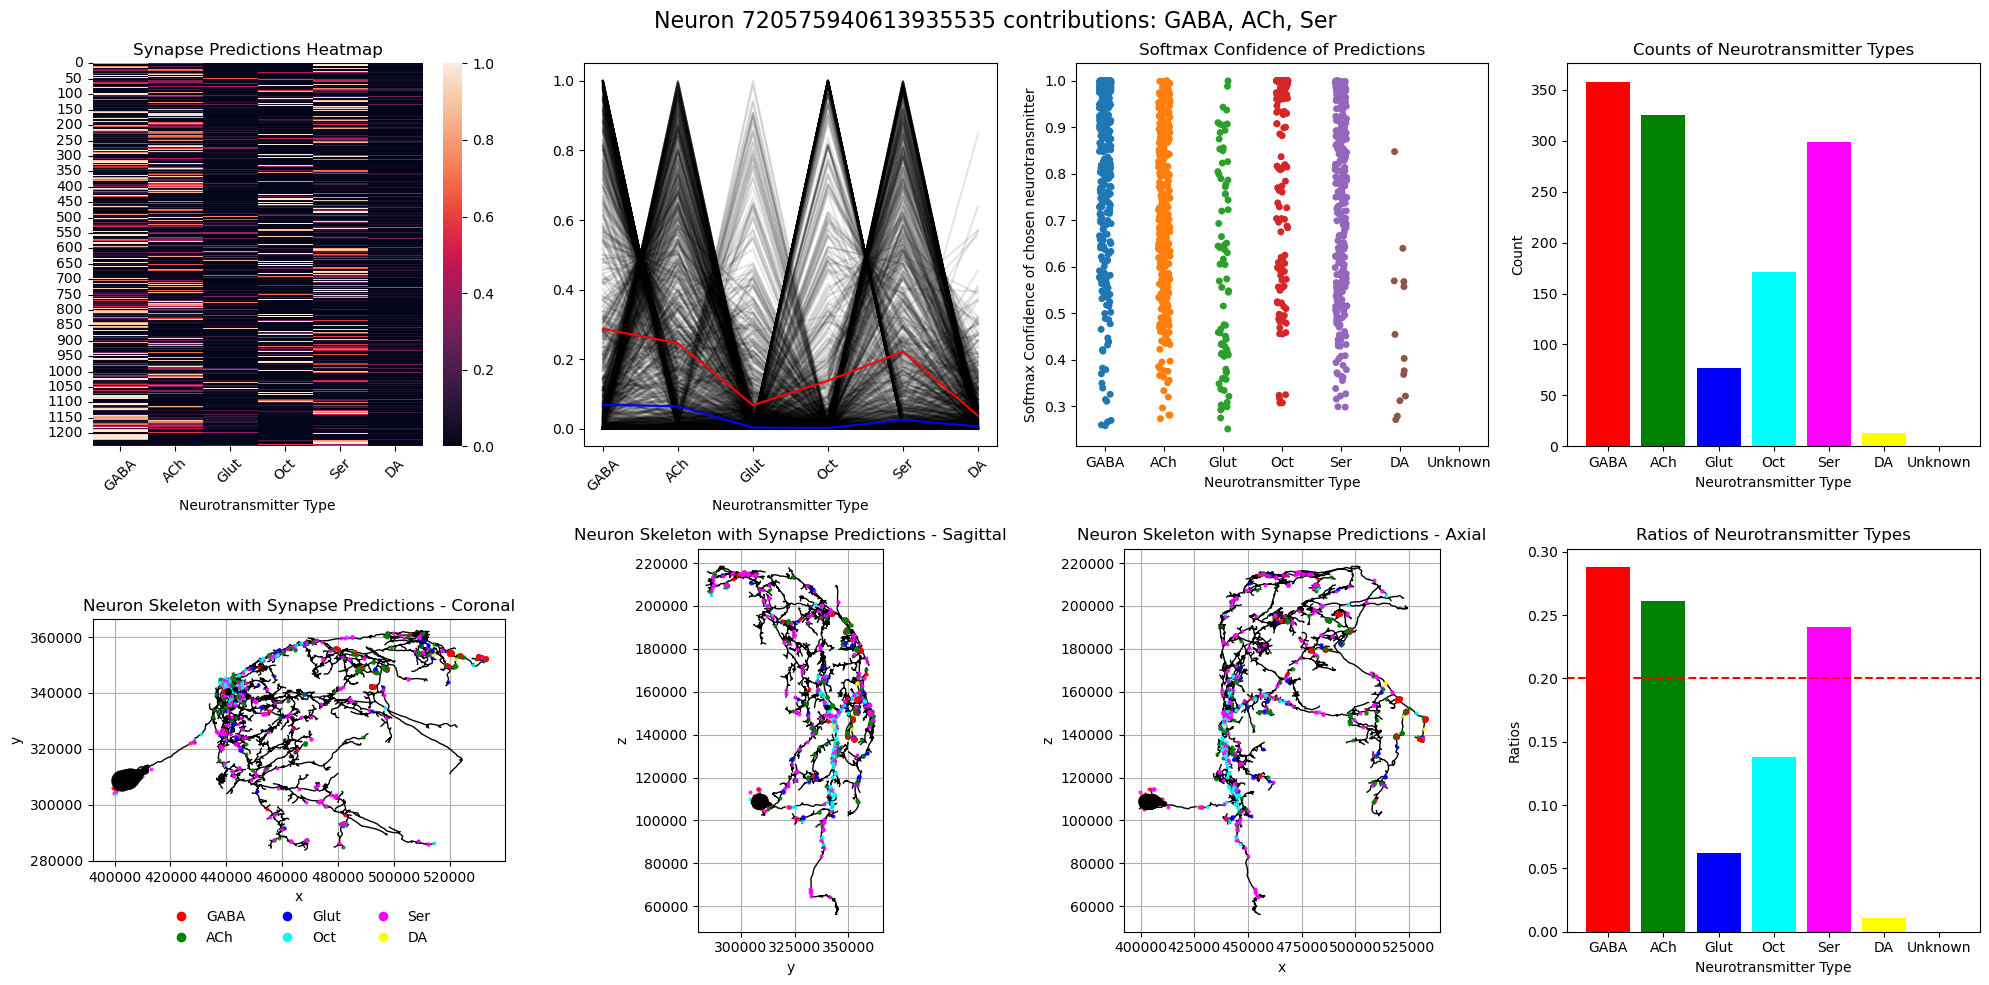

720575940630868793
nt_counts: {'GABA': 274, 'ACh': 562, 'Glut': 506, 'Oct': 137, 'Ser': 447, 'DA': 73, 'Unknown': 0}
nt_ratios: {'GABA': 0.13706853426713356, 'ACh': 0.28114057028514255, 'Glut': 0.2531265632816408, 'Oct': 0.06853426713356678, 'Ser': 0.2236118059029515, 'DA': 0.03651825912956478, 'Unknown': 0.0}


nt_counts: {'GABA': 274, 'ACh': 562, 'Glut': 506, 'Oct': 137, 'Ser': 447, 'DA': 73, 'Unknown': 0}


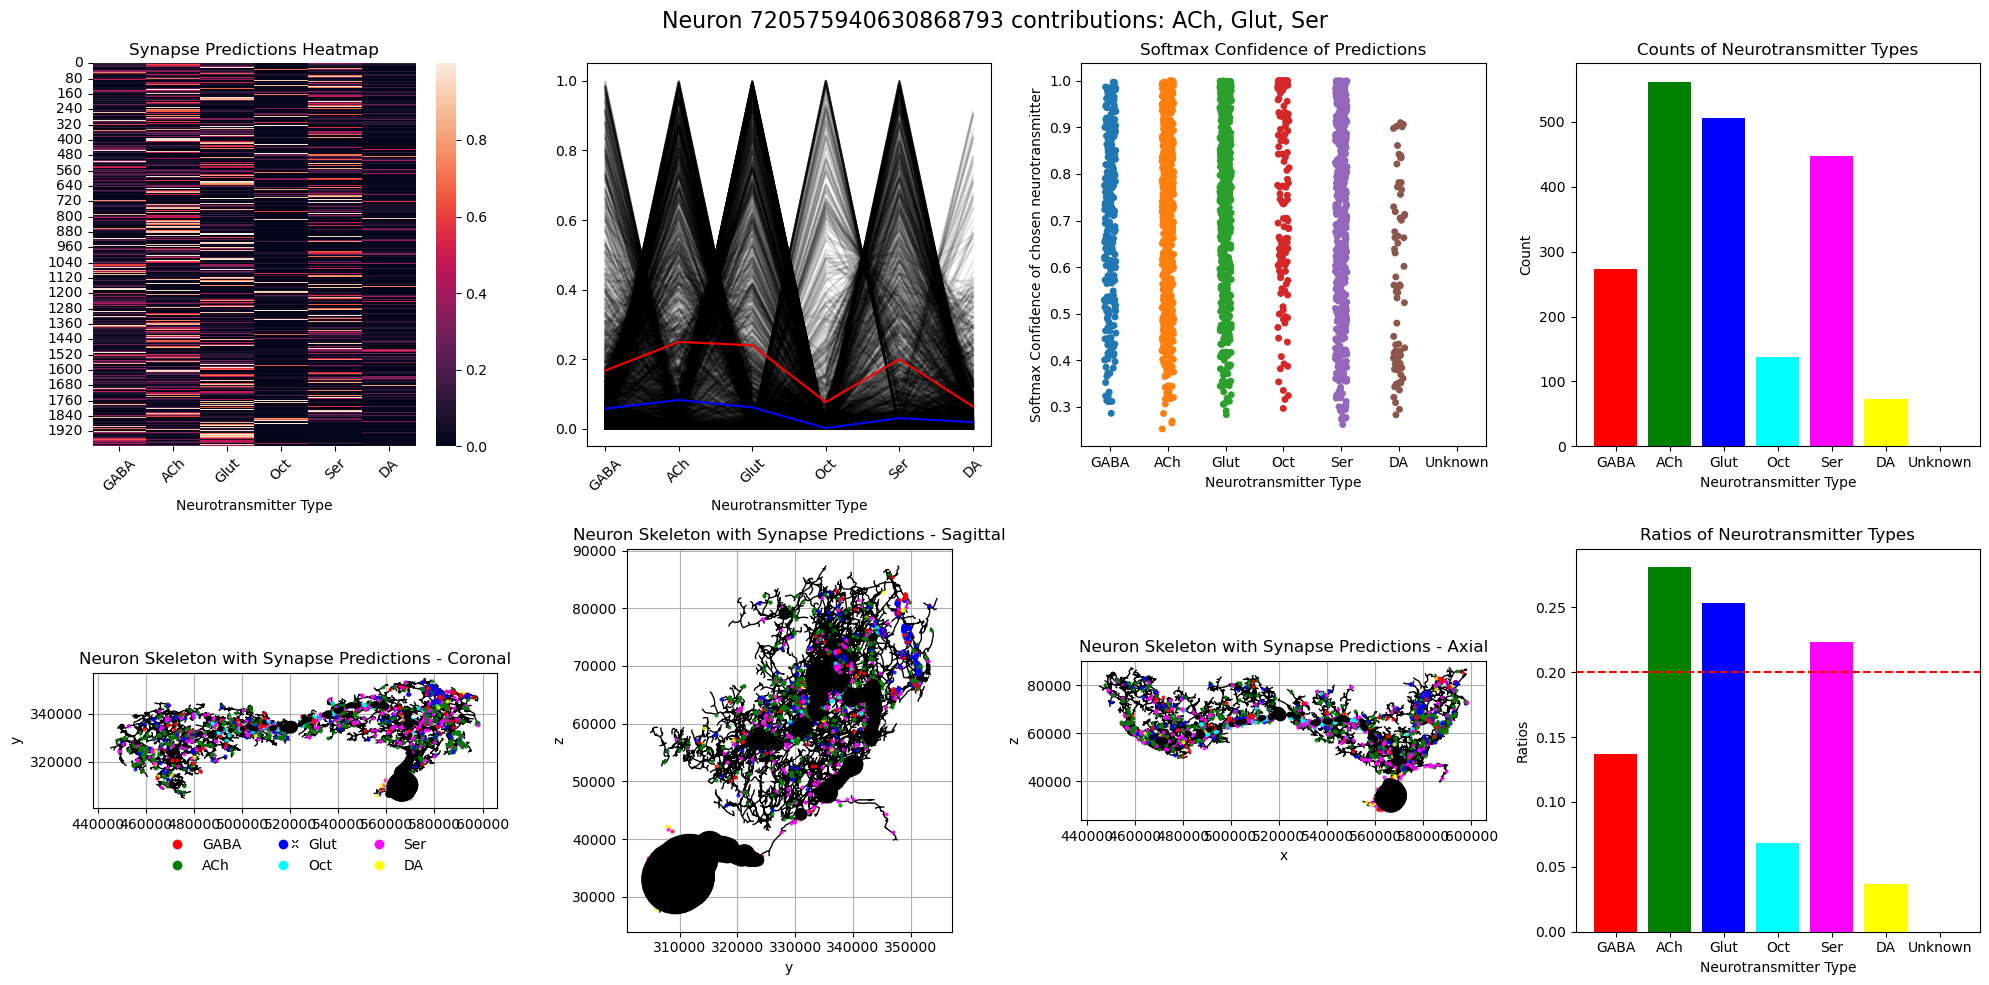

720575940607880578
nt_counts: {'GABA': 86, 'ACh': 473, 'Glut': 103, 'Oct': 174, 'Ser': 135, 'DA': 12, 'Unknown': 1}
nt_ratios: {'GABA': 0.08739837398373984, 'ACh': 0.4806910569105691, 'Glut': 0.10467479674796748, 'Oct': 0.17682926829268292, 'Ser': 0.13719512195121952, 'DA': 0.012195121951219513, 'Unknown': 0.0010162601626016261}


nt_counts: {'GABA': 86, 'ACh': 473, 'Glut': 103, 'Oct': 174, 'Ser': 135, 'DA': 12, 'Unknown': 1}


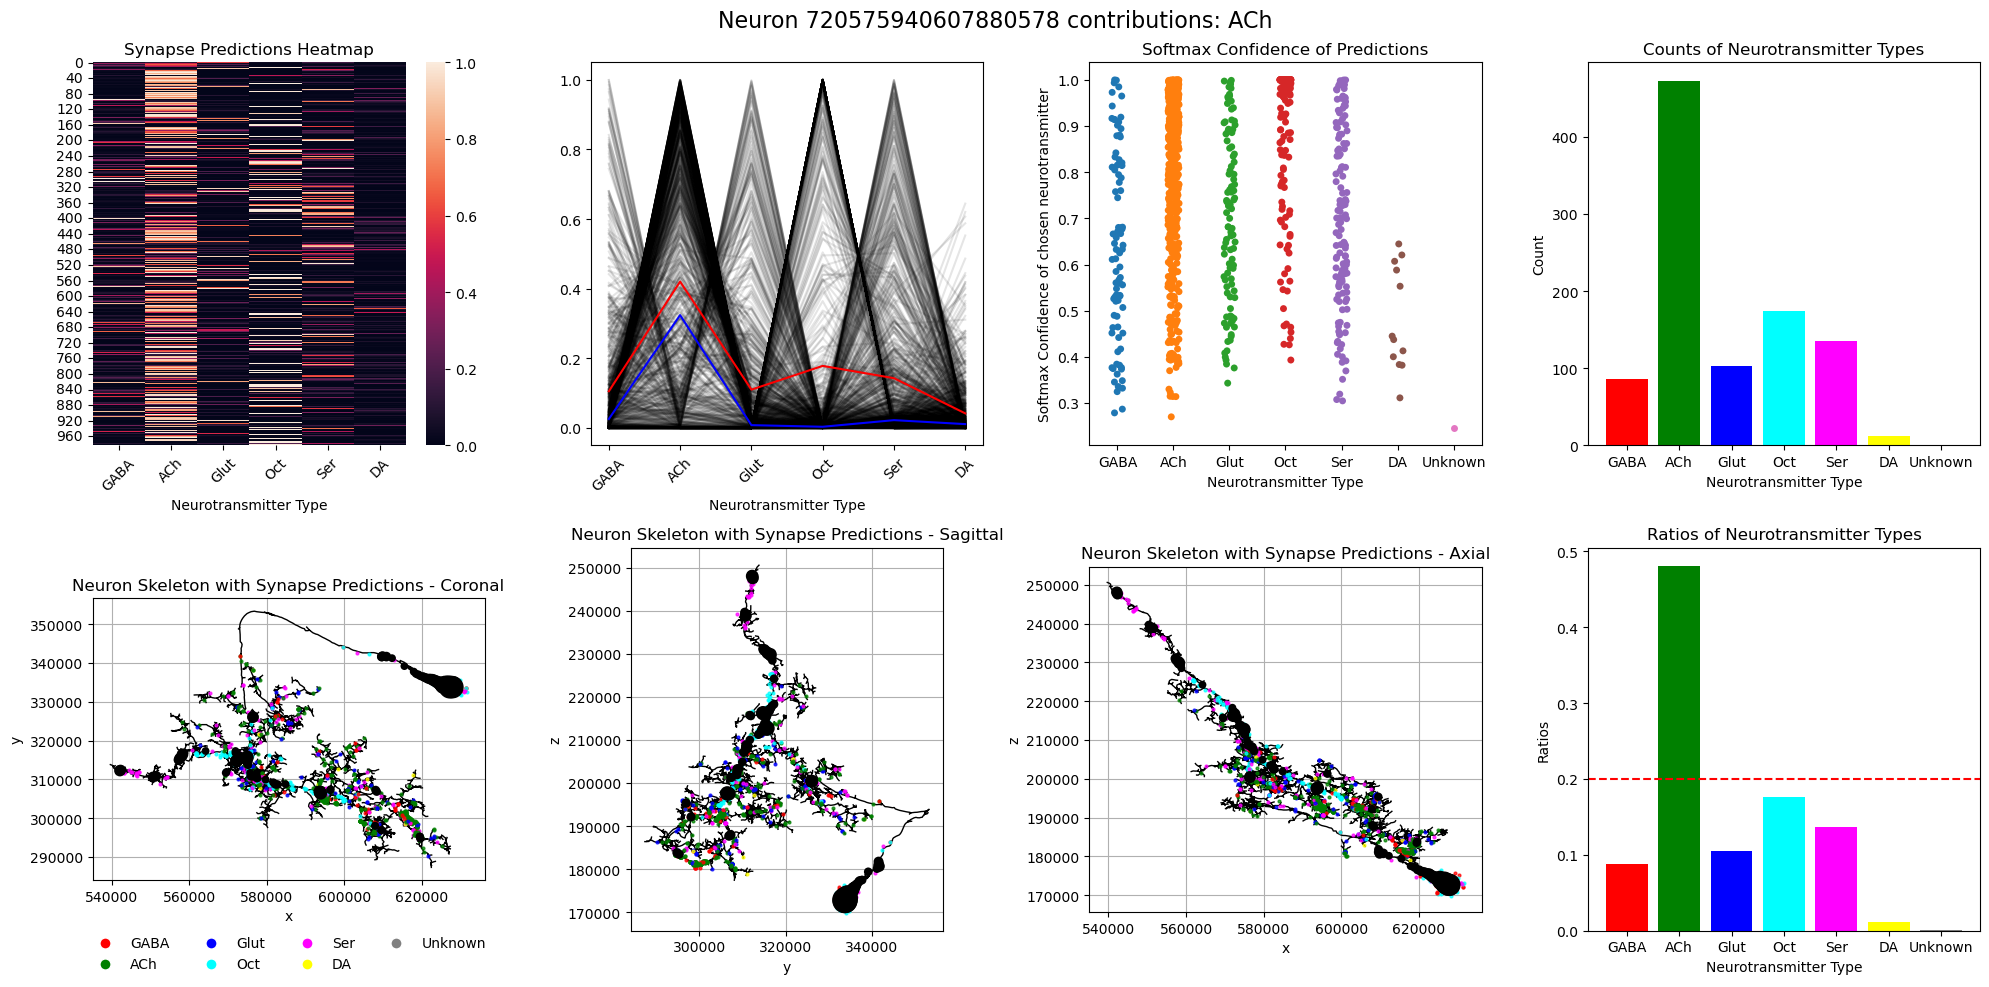

720575940636165624
nt_counts: {'GABA': 204, 'ACh': 3777, 'Glut': 187, 'Oct': 35, 'Ser': 194, 'DA': 44, 'Unknown': 5}
nt_ratios: {'GABA': 0.04588394062078273, 'ACh': 0.849527665317139, 'Glut': 0.04206027890238417, 'Oct': 0.007872244714349977, 'Ser': 0.04363472784525416, 'DA': 0.009896536212325686, 'Unknown': 0.0011246063877642825}


nt_counts: {'GABA': 204, 'ACh': 3777, 'Glut': 187, 'Oct': 35, 'Ser': 194, 'DA': 44, 'Unknown': 5}


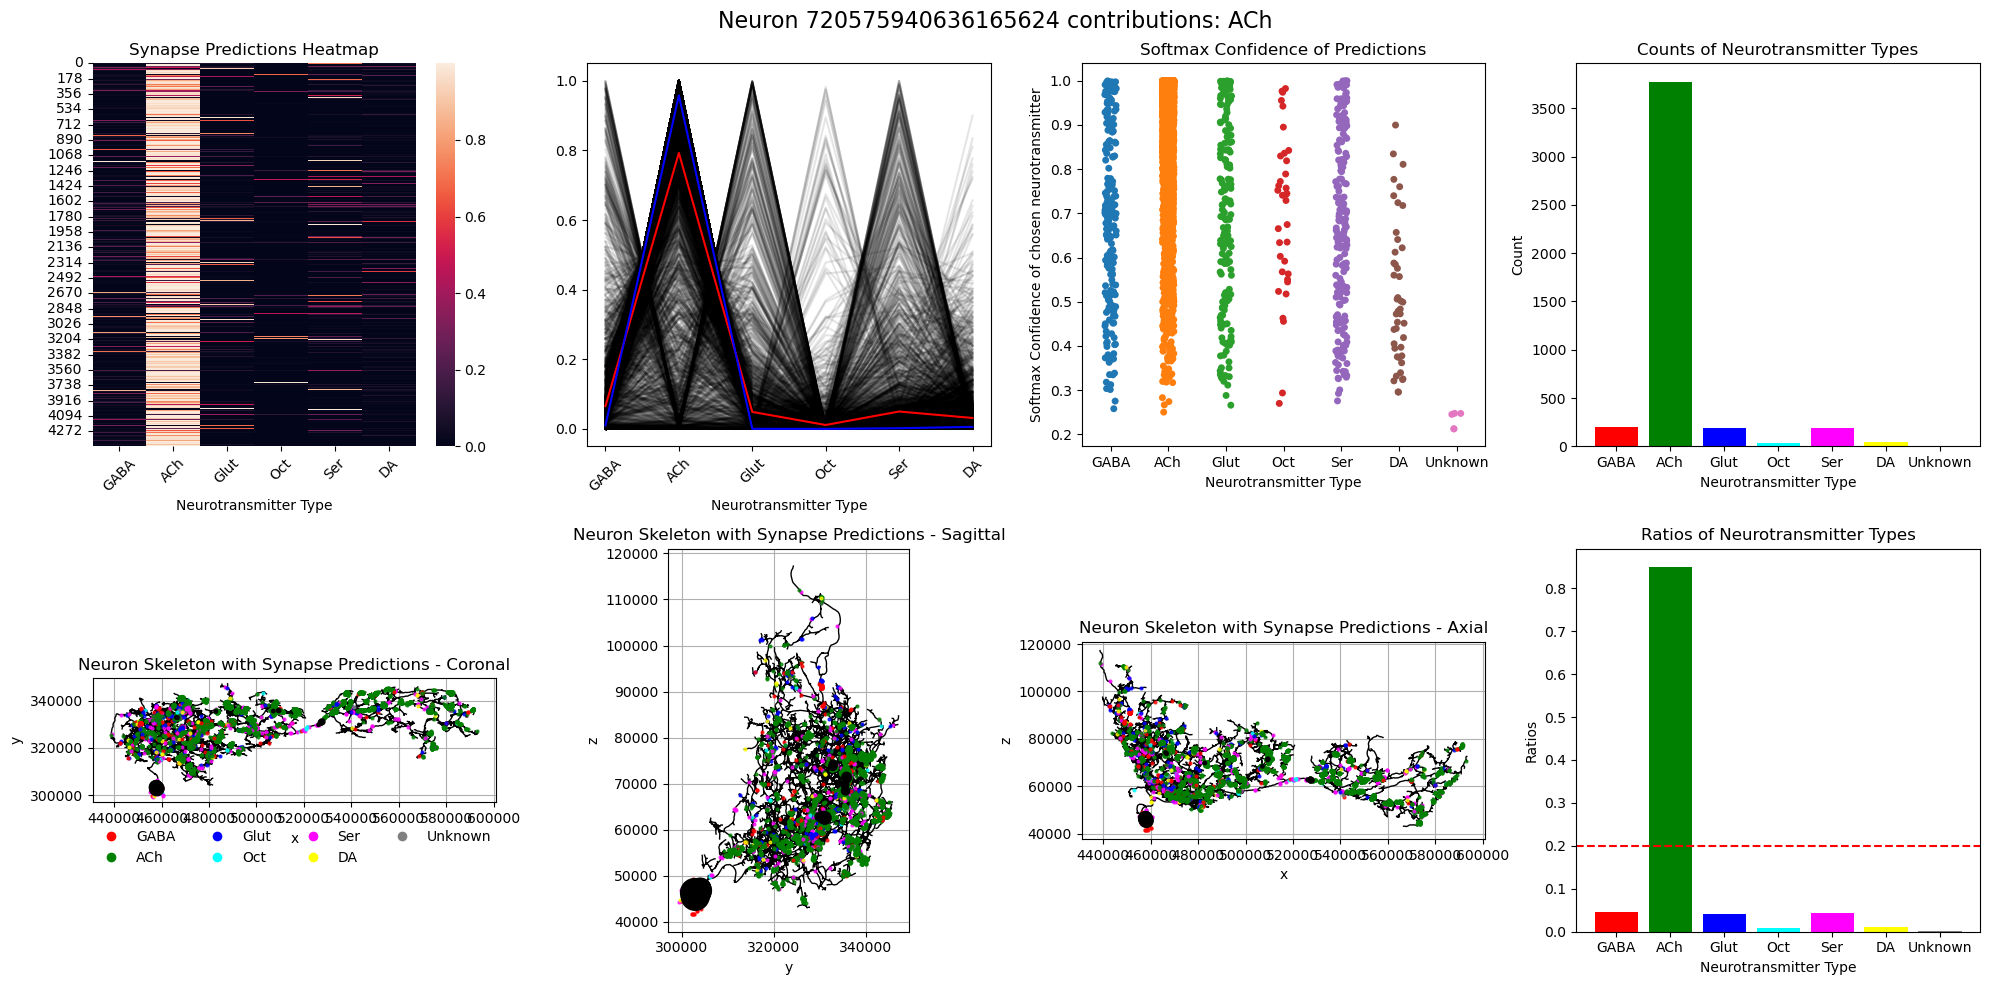

720575940633185567
nt_counts: {'GABA': 222, 'ACh': 376, 'Glut': 117, 'Oct': 49, 'Ser': 306, 'DA': 66, 'Unknown': 4}
nt_ratios: {'GABA': 0.19473684210526315, 'ACh': 0.3298245614035088, 'Glut': 0.10263157894736842, 'Oct': 0.04298245614035088, 'Ser': 0.26842105263157895, 'DA': 0.05789473684210526, 'Unknown': 0.0035087719298245615}


nt_counts: {'GABA': 222, 'ACh': 376, 'Glut': 117, 'Oct': 49, 'Ser': 306, 'DA': 66, 'Unknown': 4}


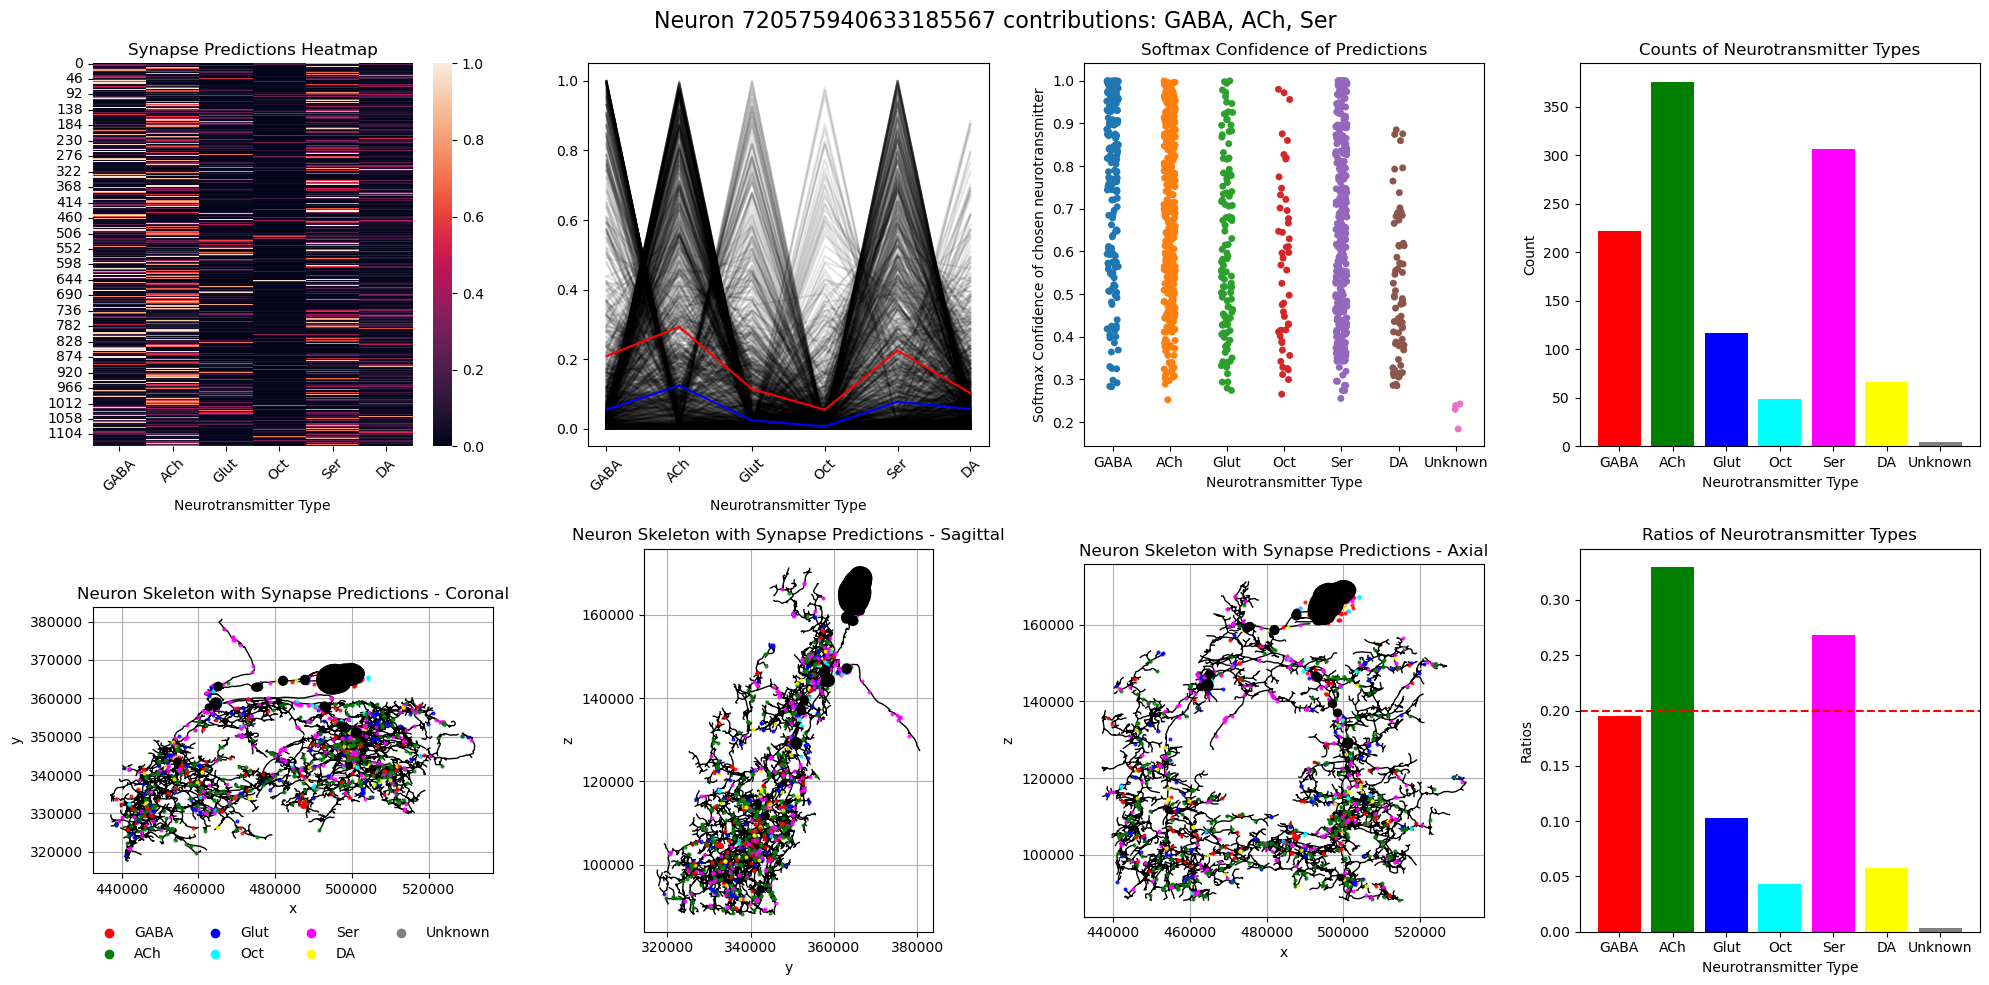

720575940635360924
nt_counts: {'GABA': 79, 'ACh': 3949, 'Glut': 58, 'Oct': 11, 'Ser': 128, 'DA': 44, 'Unknown': 5}
nt_ratios: {'GABA': 0.018483855872718766, 'ACh': 0.9239588207767899, 'Glut': 0.01357042583060365, 'Oct': 0.0025737014506317267, 'Ser': 0.029948525970987367, 'DA': 0.010294805802526907, 'Unknown': 0.001169864295741694}


nt_counts: {'GABA': 79, 'ACh': 3949, 'Glut': 58, 'Oct': 11, 'Ser': 128, 'DA': 44, 'Unknown': 5}


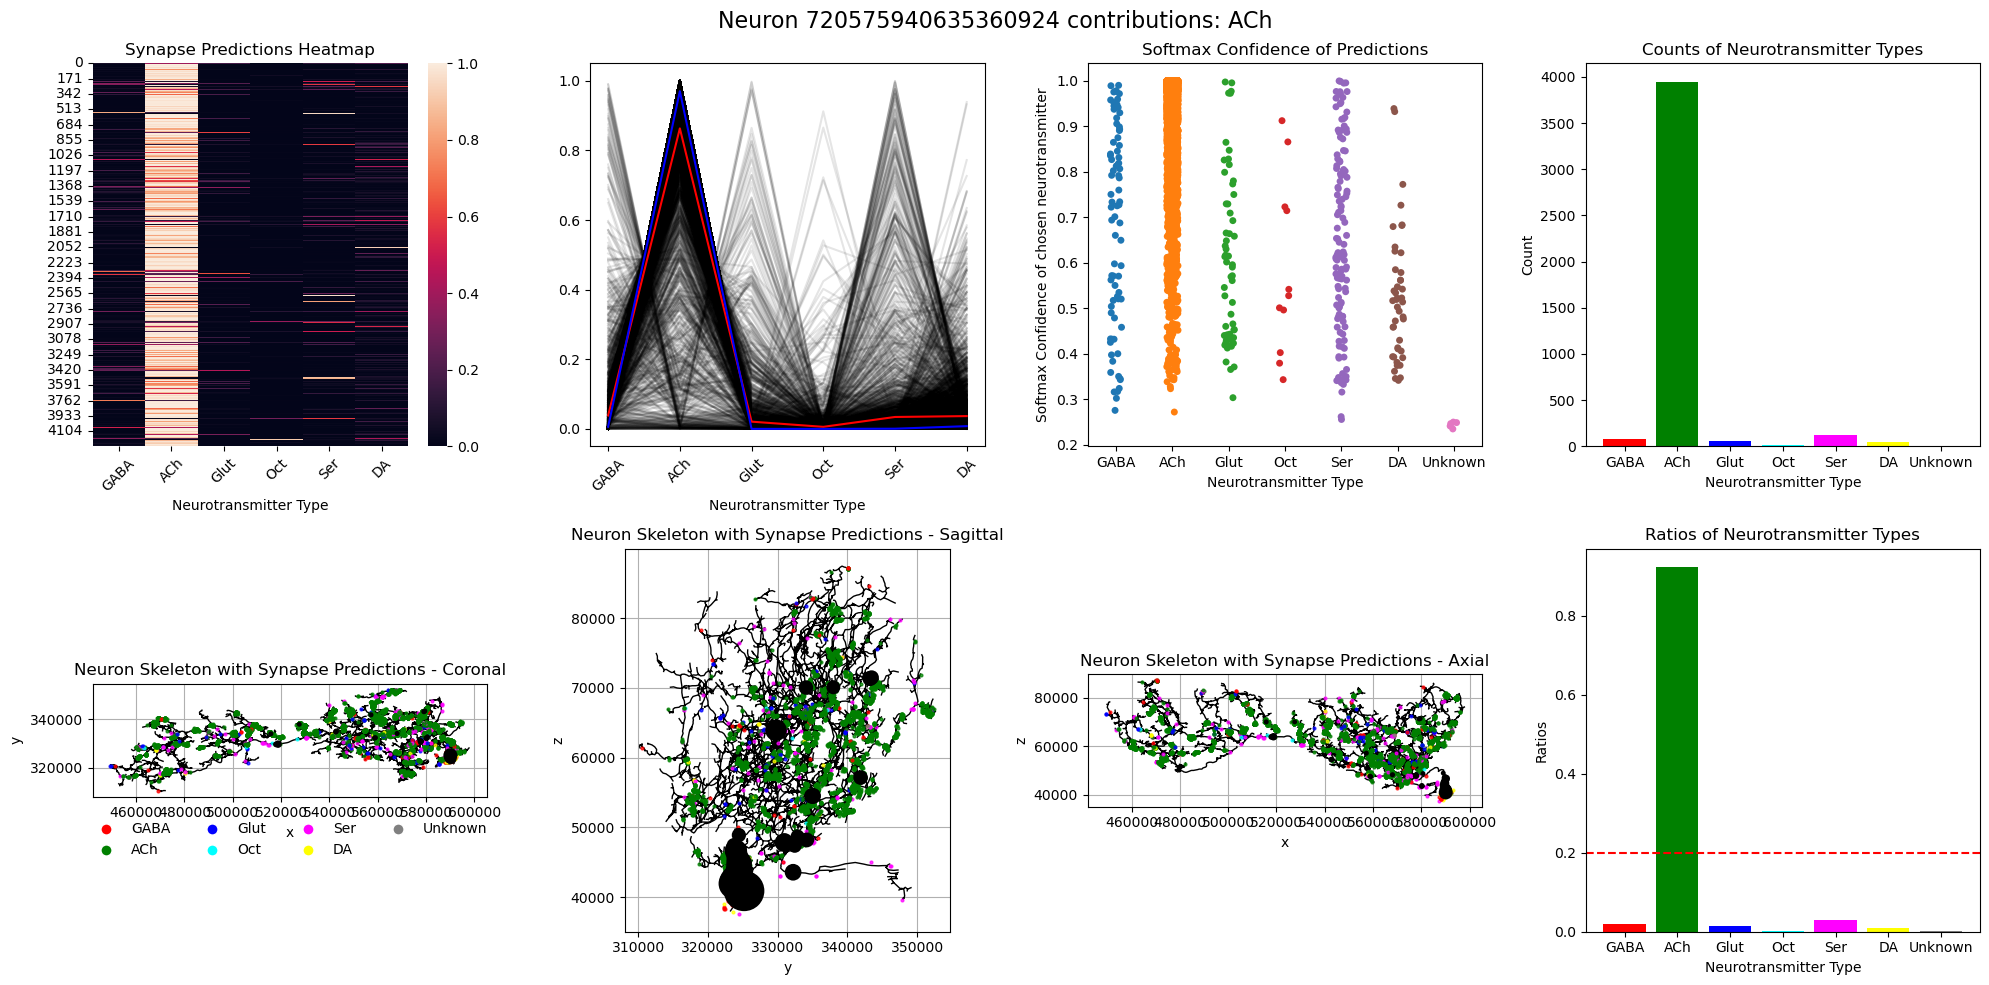

720575940620025620
nt_counts: {'GABA': 95, 'ACh': 400, 'Glut': 164, 'Oct': 39, 'Ser': 184, 'DA': 41, 'Unknown': 2}
nt_ratios: {'GABA': 0.10270270270270271, 'ACh': 0.43243243243243246, 'Glut': 0.1772972972972973, 'Oct': 0.04216216216216216, 'Ser': 0.1989189189189189, 'DA': 0.04432432432432432, 'Unknown': 0.002162162162162162}


nt_counts: {'GABA': 95, 'ACh': 400, 'Glut': 164, 'Oct': 39, 'Ser': 184, 'DA': 41, 'Unknown': 2}


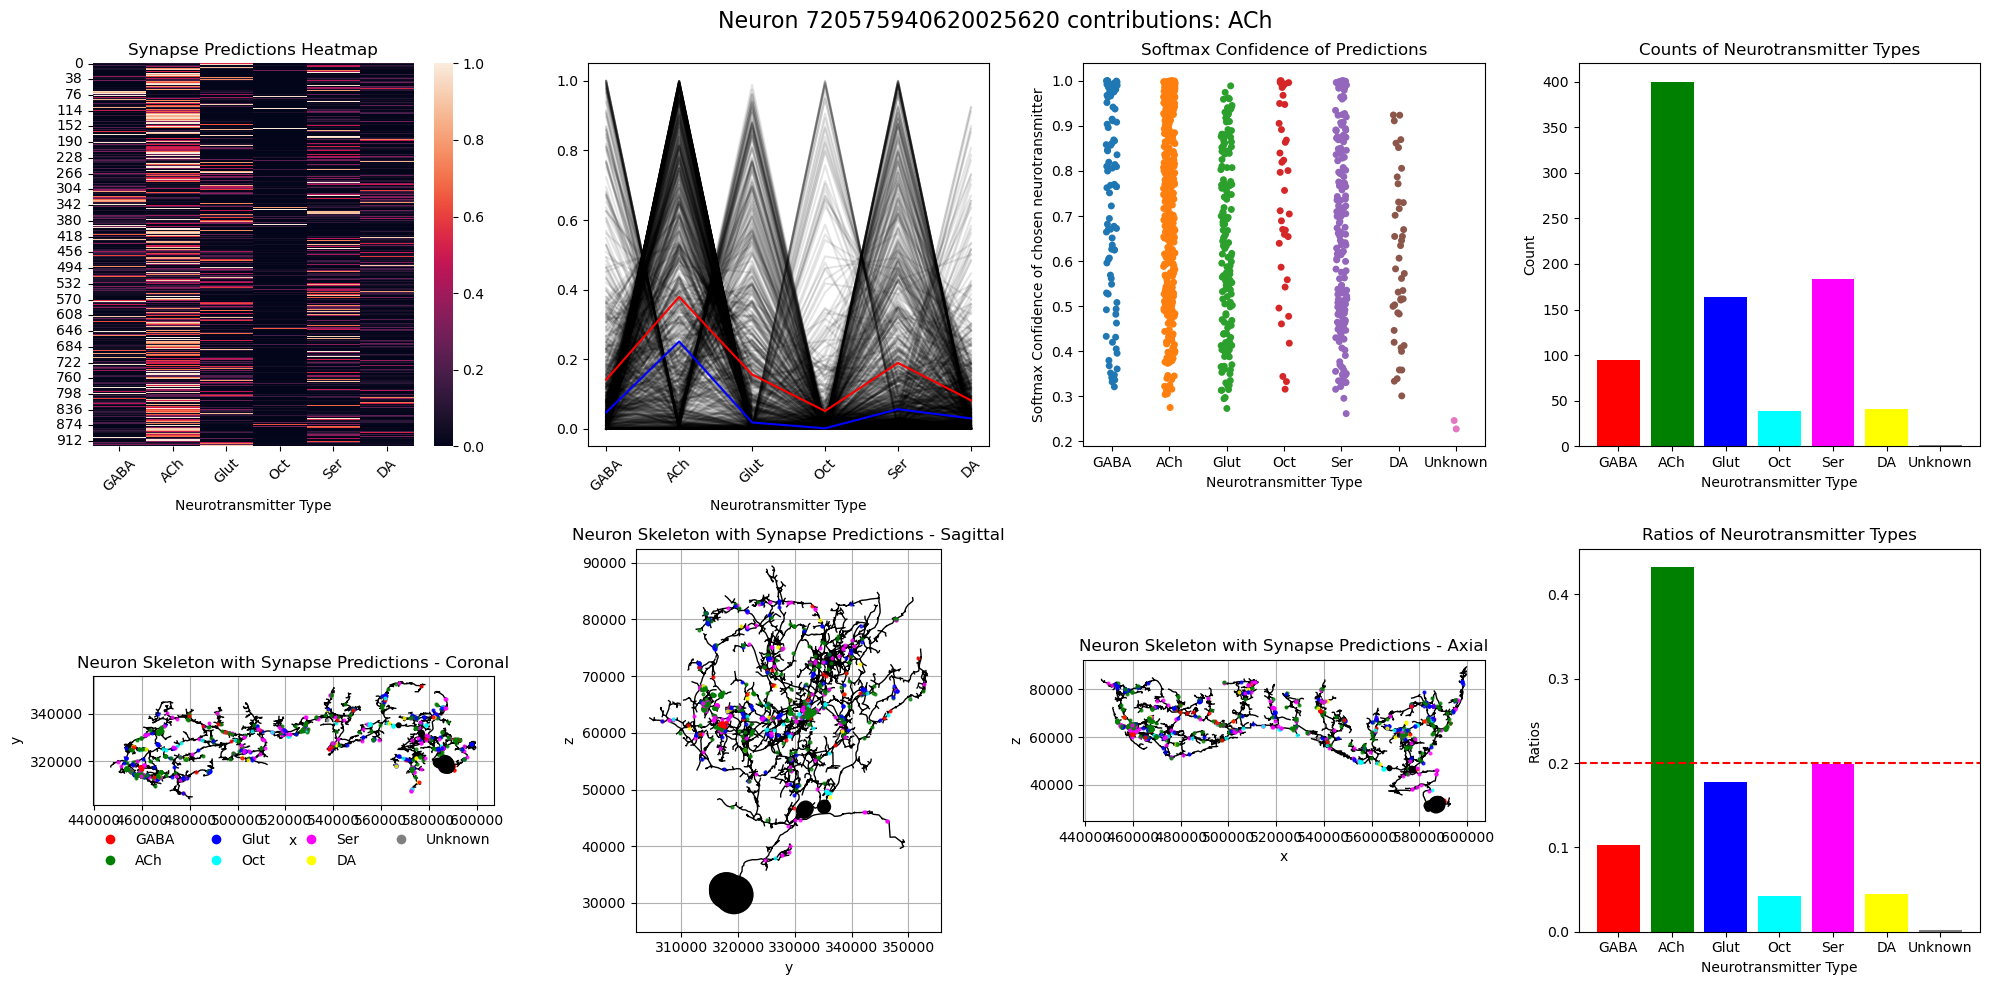

In [63]:
nts = [
    "GABA",
    "ACh",
    "Glut",
    "Oct",
    "Ser",
    "DA",
    "Unknown"
]
for row in final_nt_results_df.iterrows():
    root_id = row[1]['root_id']
    print(root_id)
    num_nts = row[1]['num_nts']

    # Now find which nts are present in the *_joint_prediction column
    present_nts = []
    for nt in nts:
        if row[1][f"{nt}_joint_prediction"]:
            present_nts.append(nt)
    # Make the string of present NTs
    present_nts_str = ", ".join(present_nts)

    suptitle_str = f'Neuron {root_id} contributions: {present_nts_str}'
    fig_path = f'./fauai-15_data/figures/synapse_predictions_neuron_{root_id}.png'

    plot_nt_contributions_for_neuron(root_id, chosen_ratio, 0.25, client, suptitle_str, fig_path)